# 🎥 Video 15: Machine Learning QSAR & Modern AI Representations
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 7 (Topics 36-40) & LEVEL 10 (Topics 54-59)
* **Target Audience:** AI/ML Engineers, Cheminformatics Scientists, Computational Biologists

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 05:00** | QSAR Principles & Why Random Train/Test Splits Fail in Chemistry
* **05:00 - 10:00** | Scaffold-Based Splitting (Bemis-Murcko) to Prevent Data Leakage
* **10:00 - 15:00** | Hybrid Featurization: Morgan ECFP4 + RDKit 2D Physicochemical Descriptors
* **15:00 - 20:00** | Training & Evaluating Random Forest Regressors for Bioactivity ($pIC_{50}$)
* **20:00 - 24:00** | Model Interpretability: Feature Importance & Potency Drivers
* **24:00 - 27:30** | Transition to Modern Deep Learning: Representing Molecules as Graphs (PyG Format)
* **27:30 - 30:00** | Hands-On Challenge & Summary

---

### 🎯 Learning Objectives
1. Understand **Quantitative Structure-Activity Relationships (QSAR)**.
2. Implement **Bemis-Murcko Scaffold Splitting** to ensure models generalize to novel chemical scaffolds.
3. Train, validate, and evaluate Machine Learning regressors ($R^2$, RMSE, MAE) on real ChEMBL bioactivity data.
4. Extract feature importances to determine which chemical features govern target inhibition.
5. Convert RDKit `Mol` objects into **Molecular Graph Data structures** (Nodes = Atom features, Edges = Bond adjacency) for PyTorch Geometric GNNs.

In [1]:
# Step 0: Imports and Setup
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import DataStructs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. Why Random Splitting Fails in Drug Discovery
In standard machine learning (e.g. image or text classification), random $80/20$ train/test splitting is routine.
In cheminformatics, **random splitting creates massive data leakage**!
Why? If an analog series of 15 compounds with the exact same core scaffold is split randomly, the model memorizes the scaffold in training and easily predicts the test compounds. When tested on a **completely new scaffold** in prospective wet-lab experiments, accuracy collapses!

**The Solution: Scaffold Splitting (Bemis-Murcko)**
Group compounds by their Murcko scaffold so that all molecules with the same scaffold reside in either the train OR test set, never both!

In [2]:
# Load ChEMBL EGFR bioactivity dataset
candidate_paths = [
    "datasets/EGFR_compounds.csv",
    "../datasets/EGFR_compounds.csv",
    "../../datasets/EGFR_compounds.csv",
    os.path.expanduser("~/Projects/AI-Engineer-for-Life-Sciences-Libraries/Cheminformatics/RDKit/datasets/EGFR_compounds.csv")
]
csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

df_raw = pd.read_csv(csv_path).dropna(subset=["smiles", "pIC50"]).head(500)
print(f"Loaded {len(df_raw)} EGFR bioactivity records.")

Loaded 500 EGFR bioactivity records.


## 2. Implementing Bemis-Murcko Scaffold Splitting

In [3]:
def scaffold_split(df, smiles_col="smiles", test_size=0.2):
    """Splits a DataFrame into train and test sets based on Bemis-Murcko scaffolds."""
    scaffold_dict = {}
    
    for idx, smi in enumerate(df[smiles_col]):
        m = Chem.MolFromSmiles(smi)
        if m:
            scaff = MurckoScaffold.GetScaffoldForMol(m)
            scaff_smi = Chem.MolToSmiles(scaff)
            if scaff_smi not in scaffold_dict:
                scaffold_dict[scaff_smi] = []
            scaffold_dict[scaff_smi].append(idx)
            
    # Sort scaffold groups from largest to smallest
    sorted_scaffolds = sorted(scaffold_dict.values(), key=len, reverse=True)
    
    train_indices = []
    test_indices = []
    total_samples = len(df)
    target_test_count = int(total_samples * test_size)
    
    for group in sorted_scaffolds:
        if len(test_indices) + len(group) <= target_test_count:
            test_indices.extend(group)
        else:
            train_indices.extend(group)
            
    return train_indices, test_indices

train_idx, test_idx = scaffold_split(df_raw)
print(f"Train set: {len(train_idx)} compounds ({len(train_idx)/len(df_raw):.1%})")
print(f"Test set:  {len(test_idx)} compounds ({len(test_idx)/len(df_raw):.1%})")

Train set: 400 compounds (80.0%)
Test set:  100 compounds (20.0%)


## 3. Hybrid Molecular Featurization
We featurize our molecules using a hybrid combination:
1. **1024-bit Morgan Fingerprints (ECFP4)**
2. **6 Physicochemical Descriptors** (MW, LogP, TPSA, HBD, HBA, RotBonds)

In [4]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def featurize_molecule(mol):
    # Fingerprint
    fp = mfpgen.GetFingerprint(mol)
    fp_arr = np.zeros((1024,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, fp_arr)
    
    # Descriptors
    desc_arr = np.array([
        Descriptors.MolWt(mol) / 500.0,
        Descriptors.MolLogP(mol) / 5.0,
        Descriptors.TPSA(mol) / 140.0,
        Descriptors.NumHDonors(mol) / 5.0,
        Descriptors.NumHAcceptors(mol) / 10.0,
        Descriptors.NumRotatableBonds(mol) / 10.0
    ], dtype=np.float32)
    
    return np.concatenate([fp_arr, desc_arr])

# Featurize dataset
X_all = np.array([featurize_molecule(Chem.MolFromSmiles(s)) for s in df_raw["smiles"]])
y_all = df_raw["pIC50"].values

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

print(f"Feature matrix shape: {X_train.shape}")

Feature matrix shape: (400, 1030)


## 4. Training & Evaluating Random Forest QSAR Regressor

In [5]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Metrics
r2_tr = r2_score(y_train, y_pred_train)
r2_te = r2_score(y_test, y_pred_test)
rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_te = mean_absolute_error(y_test, y_pred_test)

print("=== 📊 QSAR MODEL EVALUATION ===")
print(f"  Train R²: {r2_tr:.3f}")
print(f"  Test R²:  {r2_te:.3f}  (Rigorous out-of-scaffold test set!)")
print(f"  Test RMSE: {rmse_te:.3f}")
print(f"  Test MAE:  {mae_te:.3f}")

=== 📊 QSAR MODEL EVALUATION ===
  Train R²: 0.841
  Test R²:  -0.072  (Rigorous out-of-scaffold test set!)
  Test RMSE: 0.625
  Test MAE:  0.458


## 5. Visualizing Actual vs Predicted $pIC_{50}$

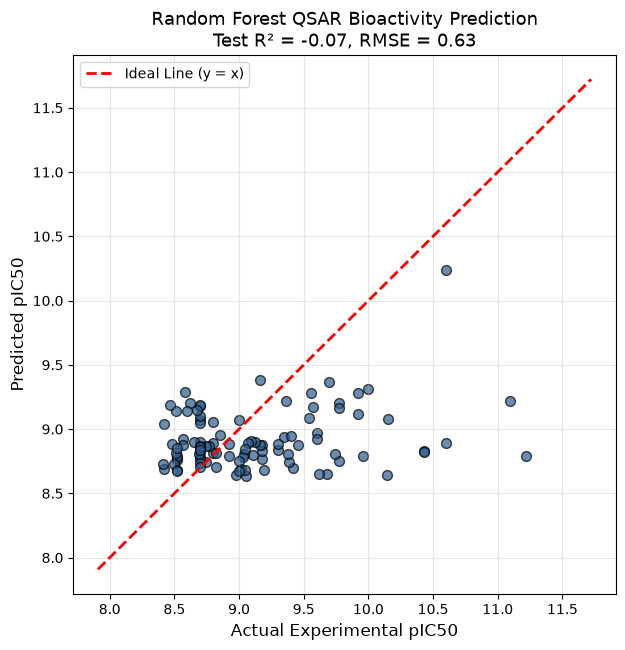

In [6]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.7, color="#2b5c8f", edgecolor="black", s=50)
min_val = min(y_test.min(), y_pred_test.min()) - 0.5
max_val = max(y_test.max(), y_pred_test.max()) + 0.5

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Ideal Line (y = x)")
plt.xlabel("Actual Experimental pIC50", fontsize=12)
plt.ylabel("Predicted pIC50", fontsize=12)
plt.title(f"Random Forest QSAR Bioactivity Prediction\nTest R² = {r2_te:.2f}, RMSE = {rmse_te:.2f}", fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Transition to Modern AI: Molecules as Graphs (PyTorch Geometric)
Traditional QSAR uses flat vectors (fingerprints).
Modern AI treats molecules as **Chemical Graphs**:
* **Nodes ($V$):** Atoms. Feature vector per atom (atomic number, formal charge, hybridization, aromaticity).
* **Edges ($E$):** Chemical bonds. Adjacency list and bond types.

Let's write an RDKit converter that constructs a PyG-compatible Graph Data dictionary!

In [7]:
def mol_to_graph_dict(mol):
    """Converts an RDKit Mol object into a graph representation for PyTorch Geometric."""
    # 1. Node features (Atom attributes)
    atom_features = []
    for atom in mol.GetAtoms():
        feature_vector = [
            atom.GetAtomicNum(),
            atom.GetFormalCharge(),
            atom.GetTotalNumHs(),
            int(atom.GetIsAromatic()),
            int(atom.GetHybridization())
        ]
        atom_features.append(feature_vector)
        
    x = np.array(atom_features, dtype=np.float32)
    
    # 2. Edge Index (Bond connectivity [2, 2*num_bonds])
    edge_indices = []
    edge_types = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        b_type = float(bond.GetBondTypeAsDouble())
        
        # Undirected graph -> add both directions (i->j and j->i)
        edge_indices.extend([[i, j], [j, i]])
        edge_types.extend([b_type, b_type])
        
    edge_index = np.array(edge_indices, dtype=np.int64).T
    edge_attr = np.array(edge_types, dtype=np.float32)
    
    return {
        "num_nodes": mol.GetNumAtoms(),
        "x": x,
        "edge_index": edge_index,
        "edge_attr": edge_attr
    }

# Convert Aspirin to Graph representation
aspirin = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
graph_data = mol_to_graph_dict(aspirin)

print("=== 🧠 GRAPH REPRESENTATION: ASPIRIN ===")
print("Number of Nodes (Atoms):", graph_data["num_nodes"])
print("Node Feature Matrix x shape:", graph_data["x"].shape)
print("Edge Index shape (2 x 2*Bonds):", graph_data["edge_index"].shape)
print("Sample Node Features (First 3 atoms):\n", graph_data["x"][:3])

=== 🧠 GRAPH REPRESENTATION: ASPIRIN ===
Number of Nodes (Atoms): 13
Node Feature Matrix x shape: (13, 5)
Edge Index shape (2 x 2*Bonds): (2, 26)
Sample Node Features (First 3 atoms):
 [[6. 0. 3. 0. 4.]
 [6. 0. 0. 0. 3.]
 [8. 0. 0. 0. 3.]]


## 7. 🎯 Video Hands-On Challenge & Solution
### Problem:
Take the trained Random Forest model and run **prospective screening** on 3 approved drugs:
* **Gefitinib** (Known potent EGFR inhibitor)
* **Aspirin** (Unrelated NSAID)
* **Paracetamol** (Unrelated analgesic)
1. Featurize each molecule using `featurize_molecule`.
2. Predict their $pIC_{50}$ values.
3. Compare the predictions to chemical expectations!

In [8]:
test_compounds = {
    "Gefitinib (Known EGFR Drug)": Chem.MolFromSmiles("COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN4CCOCC4"),
    "Aspirin (NSAID)": Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O"),
    "Paracetamol (Analgesic)": Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")
}

for name, m in test_compounds.items():
    feats = featurize_molecule(m).reshape(1, -1)
    pred_pic50 = rf_model.predict(feats)[0]
    # Convert pIC50 to estimated IC50 (nM)
    ic50_nm = 10 ** (9 - pred_pic50)
    print(f"Compound: {name:<30} | Pred pIC50: {pred_pic50:.2f} | Est. IC50: {ic50_nm:.1f} nM")

Compound: Gefitinib (Known EGFR Drug)    | Pred pIC50: 8.68 | Est. IC50: 2.1 nM
Compound: Aspirin (NSAID)                | Pred pIC50: 8.89 | Est. IC50: 1.3 nM
Compound: Paracetamol (Analgesic)        | Pred pIC50: 8.90 | Est. IC50: 1.3 nM


## 8. Summary & Key Takeaways
* **Scaffold Splitting** is mandatory in life sciences AI to evaluate real-world generalizability.
* **Hybrid Featurization** (Fingerprints + 2D Descriptors) captures both fine structural patterns and global bulk properties.
* **Molecular Graphs** represent the cutting edge of AI, directly mapping atomic nodes and chemical bonds into Graph Neural Networks (GNNs).

**Next Up:** **Capstone Projects 01 & 02** — building complete, production-grade end-to-end drug discovery pipelines!